# Reorder points and review frequency: approximating continuous review

A retailer uses the textbook rule *"order `Q` when inventory position falls to
`s`"*. **How large must `s` be when stock is only checked at fixed moments?**

Stockcast simulates discrete periods whose demand is aggregated, so it cannot
react inside a period. Classical *continuous* review cannot be simulated
exactly. What you can do is combine a **reorder-point rule** with a
**decision schedule**:

**`ReorderPointPolicy` (how much) + `DecisionSchedule` (when) + lead time**

This notebook shows the protection window that the timing implies, and how finer
review approaches the continuous-review answer.

## 1. The protection window

Decisions happen before demand. Suppose the policy does not order at epoch `t`
and the next opportunity is `u`. An order placed at `u` is usable before demand
`u + L`. So today's inventory position must survive demand `t, …, u + L − 1`:

$$H = (u - t) + L.$$

- periodic review every `R` periods: `H = L + R`;
- review every period (`review_period=1`): **`H = L + 1`**;
- an irregular schedule: `H` changes with the gap to the next opportunity.

Continuous-review formulas protect only the lead time `L`. The extra period is
the price of looking only at period boundaries. A demand quantile over `H` is a
justified basis for `s`. It is **not** a guarantee of realized service, which
also depends on undershoot, `Q`, the shortage mode, and the demand process.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stockcast import InventoryStateDataFrame, ReorderPointPolicy, SimulationEngine
from stockcast.evaluation import cycle_service_level, validate_event_frame


def poisson_quantile(probability, mean):
    """Smallest k with P(Poisson(mean) <= k) >= probability."""
    k, pmf = 0, np.exp(-mean)
    cdf = pmf
    while cdf < probability:
        k += 1
        pmf *= mean / k
        cdf += pmf
    return k

## 2. One demand path, observed at four review frequencies

We simulate 100 independent SKUs with Poisson demand of 12 units per day, drawn
in 3-hour buckets. Coarser review steps (6h, 12h, 24h) **sum the same buckets**,
so every scenario faces an identical demand path.

The physical lead time is 2 days for every scenario. In review steps that is
`L = 2 × steps per day`. The order quantity is 4 days of mean demand; unmet
demand is backordered. The demand process is known here, so any difference
comes from review timing, not from forecasting error.

In [3]:
seed = 7
n_skus, days, daily_rate = 100, 35, 12.0
lead_days, alpha, order_quantity = 2, 0.95, 4 * 12.0
finest_hours = 3
origin = pd.Timestamp("2026-01-05")
skus = [f"sku_{i:03d}" for i in range(n_skus)]
buckets = np.random.default_rng(seed).poisson(
    daily_rate * finest_hours / 24, size=(days * 24 // finest_hours, n_skus)
).astype(float)
buckets.shape

(280, 100)

In [4]:
def simulate(step_hours, s_basis="L+1"):
    """Run one review frequency; s_basis='L' copies the continuous-review formula."""
    per_day = 24 // step_hours
    lead = lead_days * per_day
    window = lead + 1                      # H = L + 1 for review every step
    basis = window if s_basis == "L+1" else lead
    s = float(poisson_quantile(alpha, daily_rate * basis / per_day))
    step, frequency = pd.Timedelta(hours=step_hours), f"{step_hours}h"

    y = buckets.reshape(-1, step_hours // finest_hours, n_skus).sum(axis=1)
    n = len(y)
    demand = pd.DataFrame({
        "unique_id": np.tile(skus, n),
        "period": np.repeat(np.arange(n), n_skus),
        "date": np.repeat([origin + (p + 1) * step for p in range(n)], n_skus),
        "y": y.reshape(-1),
    })

    # Quantile mode declares its probability; the copied textbook value is
    # passed as a planner choice, because it is not a quantile over H.
    quantile_mode = s_basis == "L+1"
    column = "reorder_q95" if quantile_mode else "planner_s"
    policy = ReorderPointPolicy(
        lead, review_period=1, policy_type="sQ",
        service_level=alpha if quantile_mode else None,
        order_quantity=order_quantity, order_quantity_source="four_days_of_mean_demand",
        allow_backorders=True,
    ).fit(
        pd.DataFrame({"unique_id": skus, column: s, "end": origin + window * step}),
        forecast_origin=origin, forecast_frequency=frequency,
        reorder_point_column=column, reorder_end_date_column="end",
        reorder_horizon=window, target_source="external_direct",
        target_probability=alpha if quantile_mode else None,
    )
    inventory = InventoryStateDataFrame(
        skus, max_lead_time=lead, allow_backorders=True,
    ).initialize_from_observed(
        pd.DataFrame({"unique_id": skus, "stock": s + order_quantity}),
        on_hand_column="stock", start_date=origin,
    )
    warmup = 7 * per_day
    result = SimulationEngine().run(
        policy, demand, inventory, n, period_frequency=frequency,
        warmup_periods=warmup, scoring_periods=n - warmup, settlement_periods=0,
        order_during_settlement=False, demand_source_name="shared_3h_poisson_path",
        random_seed=seed,
    )
    events = validate_event_frame(result.to_event_frame("scoring"))
    return {
        "review_every": frequency, "s_basis": s_basis, "L_steps": lead,
        "H_steps": window, "s_window_days": basis / per_day, "reorder_point": s,
        "cycle_service": cycle_service_level(events, {"include_partial_cycles": False}),
        "fill_rate": result.summary()["fill_rate"],
        "mean_stock": events["ending_on_hand"].mean(),
    }

## 3. Finer review approaches the continuous-review reorder point

As the review step shrinks, `H = L + 1` step approaches the pure lead time. The
reorder point falls towards the classical continuous-review value: the 95%
quantile of 2 days of demand.

In [5]:
results = pd.DataFrame([simulate(hours) for hours in (24, 12, 6, 3)])
continuous_s = poisson_quantile(alpha, lead_days * daily_rate)

assert results["reorder_point"].is_monotonic_decreasing
assert (results["reorder_point"] >= continuous_s).all()
assert (results["cycle_service"] >= alpha - 0.03).all()
results.round(3)

,review_every,s_basis,L_steps,H_steps,s_window_days,reorder_point,cycle_service,fill_rate,mean_stock
0,24h,L+1,2,3,3.000,46.0,0.997,1.000,34.595
1,12h,L+1,4,5,2.500,39.0,0.991,1.000,33.551
2,6h,L+1,8,9,2.250,36.0,0.990,0.999,33.455
3,3h,L+1,16,17,2.125,34.0,0.979,0.999,32.894


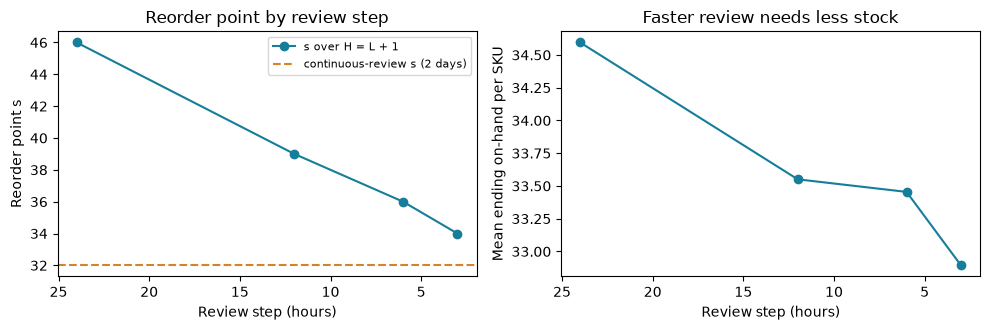

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
hours = [24, 12, 6, 3]
axes[0].plot(hours, results["reorder_point"], marker="o", color="#167d9a", label="s over H = L + 1")
axes[0].axhline(continuous_s, color="#d58228", linestyle="--", label="continuous-review s (2 days)")
axes[0].set(xlabel="Review step (hours)", ylabel="Reorder point s", title="Reorder point by review step")
axes[0].invert_xaxis()
axes[0].legend(fontsize=8)
axes[1].plot(hours, results["mean_stock"], marker="o", color="#167d9a")
axes[1].set(xlabel="Review step (hours)", ylabel="Mean ending on-hand per SKU",
            title="Faster review needs less stock")
axes[1].invert_xaxis()
fig.tight_layout()
plt.show()

The reorder point falls by about a quarter between daily and 3-hour review. Mean stock falls less (about 5%) because the order quantity `Q` dominates cycle stock in this example.

## 4. The common mistake: copying the continuous-review formula

A planner reviews **once per day** but uses the textbook continuous-review
reorder point, the 2-day lead-time quantile. Stockcast still requires the true
window `H = L + 1` in the target metadata. It cannot tell that the number
itself was computed for the wrong window, so the planner passes it in planner
mode (`service_level=None`).

In [7]:
comparison = pd.DataFrame([results.iloc[0].to_dict(), simulate(24, s_basis="L")])
assert comparison.loc[1, "cycle_service"] < comparison.loc[0, "cycle_service"] - 0.1
comparison[["review_every", "s_basis", "reorder_point", "cycle_service", "fill_rate", "mean_stock"]].round(3)

,review_every,s_basis,reorder_point,cycle_service,fill_rate,mean_stock
0,24h,L+1,46.0,0.997,1.000,34.595
1,24h,L,32.0,0.664,0.966,21.001


Leaving out the review interval under-protects every replenishment cycle. The
remedy is to size `s` over the window implied by the schedule, not to change
the engine's timing.

## 5. The same rule under any schedule

`ReorderPointPolicy` accepts any `DecisionSchedule`, and its fit validates the
matching window:

| Schedule | Window of `s` |
|---|---|
| `review_period=1` | `L + 1` |
| `PeriodicSchedule(7)` | `L + 7` |
| `ExplicitSchedule((0, 3, 10))` at `t=3` | `(10 − 3) + L` |

For irregular schedules, fit one policy snapshot per decision date (see
Notebook 04b). For `(s,S)`, `S` is a policy parameter, not a quantile; in the
literature `s` and `S` are usually chosen jointly. Supply such pairs in planner
mode (`service_level=None`).

References: the protection interval `R + L` for periodic reorder-point systems
(Silver, Pyke & Peterson, *Inventory and Production Management in Supply
Chains*); the [Stockpyl sequence-of-events discussion](https://stockpyl.readthedocs.io/en/latest/tutorial/tutorial_sim.html)
on why the review convention changes the lead-time mapping; and
[Stockpyl's periodic (s,S) optimization](https://stockpyl.readthedocs.io/en/latest/api/seio/ss.html)
(Zheng & Federgruen, 1991) for jointly chosen `s` and `S`.